<a href="https://colab.research.google.com/github/SalgadoHUB/Classical_Mechanics_II/blob/main/Tareas/Tarea3_ecsEuler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Molino en equilibrio

Tenemos un molino de luz, del cuál hemos calculado su matriz de inercia. Suponemos que su CDM está sobre la vertical (válido para pequeñas oscilaciones), de modo que podemos suponer que no hay fuerzas externas. Tenemos que estudiar entonces la  rotación del sólido libre. En esta situación, lo indicado es utilizar las Ecuaciones de Euler para el Sólido Rígido.


## Ecuaciones de Euler para un Sólido Rígido

Las ecuaciones de Euler describen el movimiento de rotación de un **sólido rígido** alrededor de su centro de masas, en un sistema de referencia ligado al cuerpo (es decir, que gira con él). Estas ecuaciones son fundamentales en la dinámica de cuerpos rígidos y se expresan en términos de los momentos principales de inercia y las componentes de la velocidad angular.

Sean $( I_1, I_2, I_3)$ los momentos principales de inercia del cuerpo respecto a sus ejes principales, y $ (\omega_1, \omega_2, \omega_3) $ las componentes de la velocidad angular $( \boldsymbol{\omega} )$ en dichos ejes. Las ecuaciones de Euler son:

\
\begin{aligned}
I_1 \frac{d\omega_1}{dt} + (I_3 - I_2)\omega_2 \omega_3 &= M_1 \\
I_2 \frac{d\omega_2}{dt} + (I_1 - I_3)\omega_3 \omega_1 &= M_2 \\
I_3 \frac{d\omega_3}{dt} + (I_2 - I_1)\omega_1 \omega_2 &= M_3
\end{aligned}


donde $( M_1, M_2, M_3 )$ son las componentes del momento externo (torque) aplicado al cuerpo respecto a los mismos ejes.

Estas ecuaciones se derivan de la segunda ley de Newton para la rotación,

$ \mathbf{M} = \frac{d\mathbf{L}}{dt} $,

considerando que el sistema de referencia está en rotación con el cuerpo. La aparición de los productos cruzados entre las componentes de $\boldsymbol{\omega} $ se debe al efecto giroscópico, que es crucial en muchos sistemas físicos, como satélites, giróscopos o vehículos en rotación.

En el caso especial en que no hay torques externos $( \mathbf{M} = \mathbf{0} )$, el sistema describe la **dinámica libre** del sólido rígido, donde pueden aparecer fenómenos como la **inestabilidad de Dzhanibekov**.

## Ecuaciones del movimiento
Escribos las ecuaciones de Euler utilizando SimPy.

In [ ]:
import sympy as sp

# Definir variables
I1, I2, I3 = sp.symbols('I1 I2 I3')  # Momentos de inercia
M1, M2, M3 = sp.symbols('M1 M2 M3')  # Momentos externos
omega1, omega2, omega3 = sp.symbols('omega1 omega2 omega3', cls=sp.Function)
t = sp.Symbol('t')  # Variable de tiempo

# Definir funciones de velocidad angular
omega1 = omega1(t)
omega2 = omega2(t)
omega3 = omega3(t)

# Definir ecuaciones de Euler
omega1_dot = sp.diff(omega1, t)
omega2_dot = sp.diff(omega2, t)
omega3_dot = sp.diff(omega3, t)

Euler1 = sp.Eq(I1 * omega1_dot + (I3 - I2) * omega2 * omega3, M1)
Euler2 = sp.Eq(I2 * omega2_dot + (I1 - I3) * omega3 * omega1, M2)
Euler3 = sp.Eq(I3 * omega3_dot + (I2 - I1) * omega1 * omega2, M3)

# Mostrar ecuaciones
display(Euler1, Euler2, Euler3)


Eq(I1*Derivative(omega1(t), t) + (-I2 + I3)*omega2(t)*omega3(t), M1)

Eq(I2*Derivative(omega2(t), t) + (I1 - I3)*omega1(t)*omega3(t), M2)

Eq(I3*Derivative(omega3(t), t) + (-I1 + I2)*omega1(t)*omega2(t), M3)

Las únicas reacciones son las que aparecen en el punto de apoyo, que no pueden general momento. Por lo tanto, imponemos las condiciones

$M1=M2=M3=0$

Además, el cuerpo tiene simetría de rotación en torno $e_3$, por lo que se cumple que

$I_1=I_2$.

Escribimos las ecuaciones y les damos nombre, para poder resolverlas más adelante.

In [ ]:


Euler1 = sp.Eq(I1 * omega1_dot + (I3 - I1) * omega2 * omega3, 0)
Euler2 = sp.Eq(I1 * omega2_dot + (I1 - I3) * omega3 * omega1, 0)
Euler3 = sp.Eq(I3 * omega3_dot, 0)

# Mostrar ecuaciones
display(Euler1, Euler2, Euler3)


Eq(I1*Derivative(omega1(t), t) + (-I1 + I3)*omega2(t)*omega3(t), 0)

Eq(I1*Derivative(omega2(t), t) + (I1 - I3)*omega1(t)*omega3(t), 0)

Eq(I3*Derivative(omega3(t), t), 0)

## Encontramos las soluciones a las ecuaciones
Para resolver el sistema de ecuaciones anterior de forma analítica, usamos la función "dsolve" de SimPy. Como argumentos de entrada, tenemos que meter las ecuaciones que hemos escrito anteriormente.

In [ ]:
# Resolver el sistema de ecuaciones
solutions = sp.dsolve([Euler1, Euler2, Euler3])

# Mostrar soluciones
display(solutions)

[Eq(omega1(t), I*C1*exp(-t*(I*C2*I1 - I*C2*I3)/I1) - I*C3*exp(t*(I*C2*I1 - I*C2*I3)/I1)),
 Eq(omega2(t), C1*exp(-t*(I*C2*I1 - I*C2*I3)/I1) + C3*exp(t*(I*C2*I1 - I*C2*I3)/I1)),
 Eq(omega3(t), C2)]

Las soluciones obtenidas de las ecuaciones de Euler nos indican lo siguiente:

Conservación de $ω_3$:
La ecuación $I_3 ω_3=0$ implica que $ω_3$ es constante en el tiempo.
Esto significa que el sólido rota alrededor del eje de inercia asociado a $I_3$ sin cambios en la velocidad angular en esa dirección.

Oscilaciones en $ω_1$ y $ω_2$
 Las ecuaciones para $ω_1$ y $ω_2$ tienen la forma de ecuaciones acopladas con términos proporcionales a $ω_3$.
Esto sugiere un comportamiento oscilatorio en estas componentes, similar a un movimiento periódico o precesión.
Interpretación física:
Cuando  $I_1 = I_2$, el cuerpo tiene simetría en los ejes $x$ e $y$, y su rotación en esos planos sigue una dinámica de precesión alrededor del eje $z$.
La velocidad angular en el plano perpendicular a zz varía de manera sinusoidal con el tiempo.

Conclusión

El sistema describe la rotación de un sólido simétrico (con $I_1 = I_2$) en ausencia de momentos externos. La velocidad angular alrededor del eje de máxima inercia $I_3$ se conserva, mientras que las componentes perpendiculares oscilan, lo que refleja el movimiento natural de precesión del cuerpo.

## Damos los valores de $I_1$, $I_3$

Utilizamos las dimensiones del molino y los momentos de inercia calculados en la actividad anterior.

In [ ]:
# Definir variables
M, L, d, h = sp.symbols('M L d h')  # Parámetros físicos
I1 = 0.5 * M * L**2 + 2 * M * (d**2 + 2 * h**2)
I3 = (1/3) * M * L**2 + 4 * M * d**2

Euler1 = sp.Eq(I1 * omega1_dot + (I3 - I1) * omega2 * omega3, 0)
Euler2 = sp.Eq(I1 * omega2_dot + (I1 - I3) * omega3 * omega1, 0)
Euler3 = sp.Eq(I3 * omega3_dot, 0)

# Mostrar ecuaciones
display(Euler1, Euler2, Euler3)

Eq((0.5*L**2*M + 2*M*(d**2 + 2*h**2))*Derivative(omega1(t), t) + (-0.166666666666667*L**2*M + 4*M*d**2 - 2*M*(d**2 + 2*h**2))*omega2(t)*omega3(t), 0)

Eq((0.5*L**2*M + 2*M*(d**2 + 2*h**2))*Derivative(omega2(t), t) + (0.166666666666667*L**2*M - 4*M*d**2 + 2*M*(d**2 + 2*h**2))*omega1(t)*omega3(t), 0)

Eq((0.333333333333333*L**2*M + 4*M*d**2)*Derivative(omega3(t), t), 0)

In [ ]:
# Resolver el sistema de ecuaciones
solutions = sp.dsolve([Euler1, Euler2, Euler3])

# Mostrar soluciones
display(solutions)

[Eq(omega1(t), 1.0*I*C1/exp(t*(0.333333333333333*I*C2*L**2 - 4.0*I*C2*d**2 + 8.0*I*C2*h**2)/(L**2 + 4.0*d**2 + 8.0*h**2))**1.0 - 1.0*I*C3*exp(t*(0.333333333333333*I*C2*L**2 - 4.0*I*C2*d**2 + 8.0*I*C2*h**2)/(L**2 + 4.0*d**2 + 8.0*h**2))),
 Eq(omega2(t), 1.0*C1/exp(t*(0.333333333333333*I*C2*L**2 - 4.0*I*C2*d**2 + 8.0*I*C2*h**2)/(L**2 + 4.0*d**2 + 8.0*h**2))**1.0 + 1.0*C3*exp(t*(0.333333333333333*I*C2*L**2 - 4.0*I*C2*d**2 + 8.0*I*C2*h**2)/(L**2 + 4.0*d**2 + 8.0*h**2))),
 Eq(omega3(t), C2)]

# Simulación de una perturbación sobre el molino
Para ver más claramente cómo es el movimiento, calculamos la evolución de forma numérica. Para ello, utilizamos numpy, y la función "solve_ivp" del módulo scipy.integrate para resolver las ecuaciones diferenciales.

In [ ]:
# Valores numéricos para simulación
param_values = {M: 1, L: 2, d: 1, h: 0.2}
I1_val = I1.subs(param_values)
I3_val = I3.subs(param_values)

In [ ]:
# Definir ecuaciones de Euler

def euler_eqs(t, omega):
    omega1, omega2, omega3 = omega
    omega1_dot = -((I3_val - I1_val) / I1_val) * omega2 * omega3
    omega2_dot = -((I1_val - I3_val) / I1_val) * omega3 * omega1
    omega3_dot = 0  # Omega3 es constante
    return [omega1_dot, omega2_dot, omega3_dot]

Como valores iniciales, hacemos que $\omega_1 = \omega_3 / 10$.

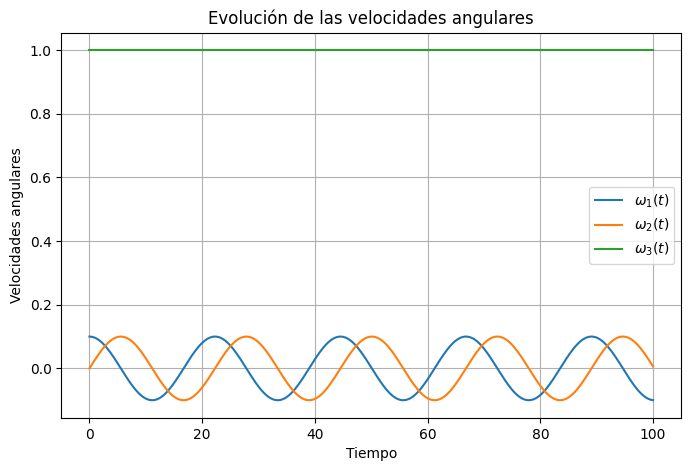

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Condiciones iniciales
omega0 = [0.1, 0.0, 1]  # Valores iniciales arbitrarios

# Resolver ecuaciones en el tiempo
t_span = (0, 100)
t_eval = np.linspace(0, 100, 300)
sol = solve_ivp(euler_eqs, t_span, omega0, t_eval=t_eval)

# Graficar soluciones
plt.figure(figsize=(8, 5))
plt.plot(sol.t, sol.y[0], label='$\omega_1(t)$')
plt.plot(sol.t, sol.y[1], label='$\omega_2(t)$')
plt.plot(sol.t, sol.y[2], label='$\omega_3(t)$')
plt.xlabel('Tiempo')
plt.ylabel('Velocidades angulares')
plt.legend()
plt.title('Evolución de las velocidades angulares')
plt.grid()
plt.show()